## Polygon Partitioning & Subdivision


### Vocabulary and Problem Context

1. **Region or Input Polygon:**
   - This is the irregular boundary (e.g., your GeoTIFF's extent or another polygon) that you want to partition.
   - Defined as a closed polygonal shape, often represented as a **shapely.geometry.Polygon** or in GeoJSON format.

2. **Partitioning:**
   - The process of dividing the polygon into smaller polygons or subregions.
   - The goal here is to create as many **subregions** as possible, each with a target area (e.g., 1 acre).

3. **Target Area:**
   - The desired area of each subregion. For example, 1 acre (~4046.86 m²).
   - Any remainder will form a smaller subregion.

4. **Compactness:**
   - Refers to the shape of the subregions, favoring more regular (e.g., circular or square-like) shapes.
   - This avoids "spindly" or elongated polygons.

5. **Spatial Packing:**
   - A mathematical problem related to fitting shapes (e.g., circles, hexagons, or squares) into a bounded area with minimal gaps or overlaps.
   - Common approaches include:
     - **Hexagonal Tiling:** Provides the most efficient packing in a 2D plane for compact regions.
     - **Square Grid Tiling:** Easier to compute but less efficient.

6. **Polygon Clipping:**
   - Cutting out portions of shapes when they overlap or exceed the bounds of the region polygon.
   - Libraries like `shapely` or `clipper` are often used for this step.

7. **Centroidal Voronoi Tessellation (CVT):**
   - A more advanced method to partition a region into compact areas of nearly equal size while maintaining adjacency constraints.
   - This method adapts the partition to the specific shape of the input polygon.

8. **Optimization Constraints:**
   - Maximizing the number of subregions while meeting area constraints.
   - Ensuring geometric and topological validity (e.g., no overlaps, no gaps).

---

### Known Solutions and Techniques

1. **Regular Tiling (Hexagonal or Square):**
   - Simpler and faster to compute.
   - Best for polygons that approximate a rectangular or compact shape.
   - Example: Use a grid of hexagons or squares to cover the region, then clip the grid to the polygon.

2. **Voronoi-Based Partitioning:**
   - A dynamic method that adjusts the location of subregions iteratively.
   - Ensures nearly equal areas while conforming to the shape of the polygon.
   - Tools: `scipy.spatial.Voronoi` or `geovoronoi`.

3. **Centroidal Voronoi Tessellation (CVT):**
   - A refinement of Voronoi tessellation that iteratively adjusts cell centroids to equalize areas.
   - Computationally intensive but produces high-quality partitions.

4. **Geometric Optimization:**
   - Use algorithms like **linear programming** or **simulated annealing** to find optimal partition configurations.
   - Useful for irregular polygons where packing circles or squares is challenging.

5. **Shape Packing with Overlap Clipping:**
   - Generate a grid of candidate shapes (e.g., circles) and clip them to the polygon.
   - Sort and validate based on area constraints.

In [106]:
import sys
from pathlib import Path

# Add the parent directory to the Python path
# So we can find local modules e.g. "plant_search"
sys.path.append(str(Path.cwd().parent))

from plant_search.load_image import load_image, plot_image


# file_path = 'input/ESPG-4326-orthophoto.tif'
# file_path = 'input/MADRID_RGB.tif'
# file_path = '../input/aerial-trees.jpg'

# file_path = '../input/DJI_0010.JPG'
# file_path = '../input/DJI_0015.JPG'
# file_path = '../input/DJI_0093.JPG'
# file_path = '../input/DJI_0119.JPG'
file_path = '../input/IGNORE_Brewster-ortho.tif'


## Determine Region Outline

Many of our geotiffs will have a transparent border around the perimeter of our region. Rarely, if ever, will we see a perfectly rectangular area of interest. We must therefore extract the boundaries before we attempt to partition.

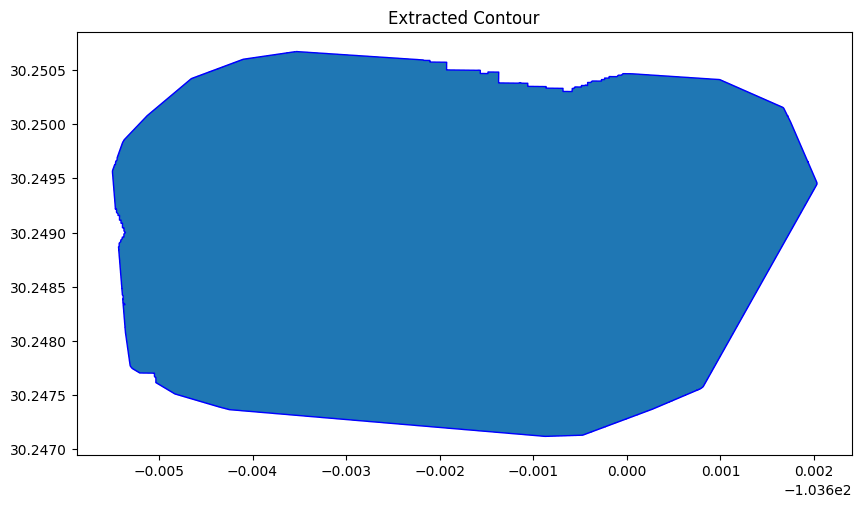

In [125]:
import cv2
import rasterio
from rasterio.plot import show
from rasterio.features import shapes
from shapely.geometry import shape, mapping
import geopandas as gpd
from shapely.geometry import Polygon, MultiPolygon
from skimage.measure import find_contours
import matplotlib.pyplot as plt
from scipy.ndimage import binary_dilation, binary_erosion
import numpy as np

def region_mask(geotiff_path):
    """
    Generate and plot a mask where RGB values are all zero, or where alpha is one (if present).
    """
    with rasterio.open(geotiff_path) as src:
        # Ensure the GeoTIFF has at least 3 bands (for RGB)
        if src.count < 3:
            raise ValueError("GeoTIFF must have at least 3 bands for RGB.")

        # Read RGB bands
        r = src.read(1)
        g = src.read(2)
        b = src.read(3)

        # Initialize mask where all RGB are zero
        mask = ~( (r == 0) & (g == 0) & (b == 0) )

        # Check for alpha channel (usually the 4th band)
        if src.count >= 4:
            alpha = src.read(4)
            mask |= (alpha == 1)

    # Plot the mask
    # plt.figure(figsize=(10, 10))
    # plt.imshow(mask, cmap="gray")
    # plt.title("Custom Mask (Valid Data Regions)")
    # plt.colorbar(label="Valid Data Mask (True/False)")
    # plt.show()

    return mask


def fast_binary_edge(geotiff_path):
    """
    Quickly extract the edge of a binary mask and create a perimeter polygon.
    
    Parameters:
        geotiff_path (str): Path to the GeoTIFF file.
    
    Returns:
        GeoDataFrame: Perimeter as a polygon.
    """
    with rasterio.open(geotiff_path) as src:
        # Read the first band
        data = src.read(1)

        # Create a binary mask for valid data
        mask = (data != 0)

        # Perform binary erosion and find the edge
        eroded_mask = binary_erosion(mask)
        edge_mask = mask & ~eroded_mask  # Pixels on the edge of the valid region

        # Get coordinates of edge pixels
        edge_coords = np.column_stack(np.where(edge_mask))
        
        # Convert pixel indices to spatial coordinates
        edge_coords_spatial = [src.xy(row, col) for row, col in edge_coords]

        # Create a polygon from the edge
        edge_polygon = Polygon(edge_coords_spatial)

    # Convert to GeoDataFrame
    return gpd.GeoDataFrame({"geometry": [edge_polygon]}, crs=src.crs)


def extract_contour_opencv(geotiff_path):
    """
    Extract the contour of a binary mask using OpenCV's findContours.
    
    Parameters:
        geotiff_path (str): Path to the GeoTIFF file.
    
    Returns:
        GeoDataFrame: Contour as a polygon.
    """
    with rasterio.open(geotiff_path) as src:
        # Read the first band
        data = src.read(1)

        # Create a binary mask for valid data
        mask = (data != 0).astype(np.uint8)  # Convert to uint8 for OpenCV

        # Find contours in the binary mask
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        # Extract the largest contour (assume it's the primary region)
        largest_contour = max(contours, key=cv2.contourArea)

        # Convert contour points to spatial coordinates
        contour_coords = [src.xy(int(pt[0][1]), int(pt[0][0])) for pt in largest_contour]

        # Create a polygon from the contour
        contour_polygon = Polygon(contour_coords)

    # Convert to GeoDataFrame
    return gpd.GeoDataFrame({"geometry": [contour_polygon]}, crs=src.crs)


# contour_gdf = extract_contour(file_path)
# contour_gdf = extract_fast_contour(file_path)
# contour_gdf = fast_binary_edge(file_path)
contour_gdf = extract_contour_opencv(file_path)


# Plot the contour
contour_gdf.plot(edgecolor="blue", figsize=(10, 10))
plt.title("Extracted Contour")
plt.show()


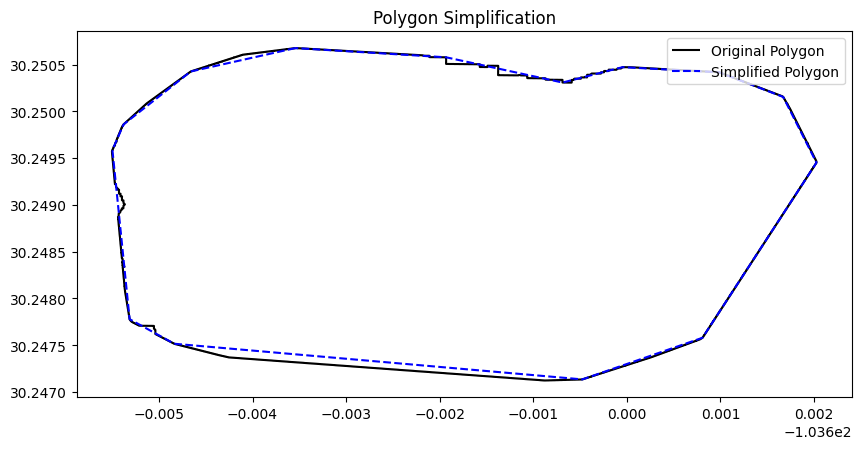

In [128]:
from shapely.geometry import Polygon

def simplify_polygon(polygon, tolerance=0.001):
    """
    Simplify a polygon by reducing its vertices.
    
    Parameters:
        polygon (Polygon): Input polygon to simplify.
        tolerance (float): Tolerance for simplification. Higher values result in greater simplification.
        
    Returns:
        Polygon: Simplified polygon.
    """
    return polygon.simplify(tolerance, preserve_topology=True)

# Simplify the region polygon
contour_polygon = contour_gdf.geometry.iloc[0]
simplified_polygon = simplify_polygon(contour_polygon, tolerance=0.0001)

# Visualize the original and simplified polygons
fig, ax = plt.subplots(figsize=(10, 10))
gpd.GeoDataFrame({"geometry": [contour_polygon]}).boundary.plot(ax=ax, color="black", label="Original Polygon")
gpd.GeoDataFrame({"geometry": [simplified_polygon]}).boundary.plot(ax=ax, color="blue", linestyle="--", label="Simplified Polygon")
plt.legend()
plt.title("Polygon Simplification")
plt.show()


### Region Analysis
- How big is our region?
- Which CRS do we need to re-project to? How can we handle this automatically?


In [108]:
def calculate_polygon_area(polygon, crs=None):
    """
    Calculate the area of a polygon in square meters.
    
    Parameters:
        polygon (Polygon): The polygon to calculate the area of.
        crs (CRS): The CRS of the polygon. If geographic, reproject to projected CRS.
    
    Returns:
        float: Area of the polygon in square meters.
    """
    if crs and crs.is_geographic:
        # Reproject to a projected CRS (e.g., EPSG:3857 or UTM zone)
        polygon_gdf = gpd.GeoDataFrame({"geometry": [polygon]}, crs=crs)
        projected_gdf = polygon_gdf.to_crs(epsg=3857)  # Web Mercator
        return projected_gdf.geometry.iloc[0].area
    else:
        # Return the area directly if already in a projected CRS
        return polygon.area


In [109]:
contour_polygon = contour_gdf.geometry.iloc[0]

contour_gdf_projected = contour_gdf.to_crs(epsg=32614)  # Example: UTM Zone 14N
contour_proj_polygon = contour_gdf_projected.geometry.iloc[0]

# Assuming the region polygon is in WGS84 (degrees)
polygon_area_m= calculate_polygon_area(contour_proj_polygon, crs=contour_gdf_projected.crs)
area_acres = polygon_area_m / 4046.86

# Print the area
print(f"Area of the Region: {polygon_area_m:.2f} square meters")
print(f"Area of the Region: {area_acres:.2f} acres")

# Reference against online tools:
# Area should be ~57.4 acres
# https://www.mapdevelopers.com/area_finder.php?polygons=%5B%5B%5B%5B30.247530683301086%2C-103.59922565771598%5D%2C%5B30.247099711872085%2C-103.60048093153495%5D%2C%5B30.24734068537719%2C-103.6041823799755%5D%2C%5B30.2476604377697%2C-103.60533036543387%5D%2C%5B30.24955170118369%2C-103.60562070950468%5D%2C%5B30.250098511178628%2C-103.60518619164426%5D%2C%5B30.25064995207441%2C-103.60372706994016%5D%2C%5B30.250480812969077%2C-103.60055669888456%5D%2C%5B30.250105462133558%2C-103.59829827889402%5D%2C%5B30.249549384185716%2C-103.59792276963194%5D%2C%5B30.247530683301086%2C-103.59922565771598%5D%5D%2C%22%23AAAAAA%22%2C%22%23000000%22%2C0.4%5D%5D


Area of the Region: 231689.31 square meters
Area of the Region: 57.25 acres


## Hexagon Tiling

Starting with regular hexagons 

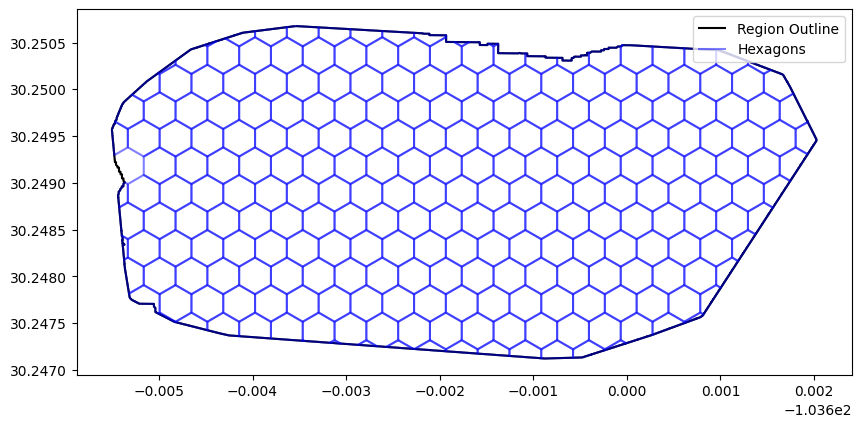

In [110]:
import geopandas as gpd
from shapely.geometry import Polygon, Point
import numpy as np
import matplotlib.pyplot as plt

# Function to calculate hexagon side length from area
def calculate_hex_side_length(target_area):
    """
    Calculate the side length of a hexagon given the target area.
    Formula: Area = (3 * sqrt(3) * s^2) / 2, solve for s.
    """
    return np.sqrt((2 * target_area) / (3 * np.sqrt(3)))

# Function to generate a hexagonal grid
def generate_hex_grid(polygon, target_area):
    """
    Generate a hexagonal grid that covers the polygon's bounding box.
    Adjusts for proper tiling with offset rows.
    
    Parameters:
        polygon (shapely.geometry.Polygon): Input polygon defining the region of interest.
        target_area (float): Target area for each hexagon.
    
    Returns:
        GeoDataFrame: Hexagonal grid clipped to the polygon.
    """
    # Calculate hexagon side length from target area
    hex_side_length = np.sqrt((2 * target_area) / (3 * np.sqrt(3)))
    # hex_width = 2 * hex_side_length
    # hex_height = np.sqrt(3) * hex_side_length

    hex_width = np.sqrt(3) * hex_side_length # Because our hexagon is rotated
    hex_height = 2 * hex_side_length

    # Get the bounding box of the input polygon
    minx, miny, maxx, maxy = polygon.bounds

    # Initialize a list to store hexagons
    hexagons = []

    # Generate hexagon centers with offsets
    y = miny
    row = 0
    while y < maxy + hex_height:
        x = minx + (row % 2) * (hex_width * 0.5)  # Offset every other row by half the hex width
        while x < maxx + hex_width:
            # Create a hexagon centered at (x, y)
            hexagon = create_hexagon(x, y, hex_side_length)
            hexagons.append(hexagon)
            x += hex_width * 1  # Move to the next hexagon center in the row
        y += hex_height * 0.75
        row += 1

    # Clip hexagons to the polygon
    hexagons_clipped = [hexagon.intersection(polygon) for hexagon in hexagons if hexagon.intersects(polygon)]

    # Create a GeoDataFrame
    return gpd.GeoDataFrame({"geometry": hexagons_clipped})

# Helper function to create a hexagon
def create_hexagon(x_center, y_center, side_length):
    """
    Create a hexagon centered at (x_center, y_center) with a given side length.
    """
    angle_offset = np.pi / 6  # 30 degrees
    return Polygon([
        (
            x_center + side_length * np.cos(angle_offset + i * np.pi / 3),
            y_center + side_length * np.sin(angle_offset + i * np.pi / 3)
        )
        for i in range(6)
    ])



contour_polygon = contour_gdf.geometry.iloc[0]

# Target area in square units (adjust based on your needs)
target_area = 0.0000001  # Replace with your target area

# Generate hexagonal grid
hex_grid = generate_hex_grid(contour_polygon, target_area)

# Plot the result
fig, ax = plt.subplots(figsize=(10, 10))
gpd.GeoDataFrame({"geometry": [contour_polygon]}).boundary.plot(ax=ax, color="black", label="Region Outline")
hex_grid.boundary.plot(ax=ax, color="blue", alpha=0.5, label="Hexagons")
plt.legend()
plt.show()


### Hexagonal Partition Counting and Analysis

- How many regions did we create?
- What amount of space do these hexagons represent?
- How many tiles were clipped from the border?

In [111]:
def count_hexagons(hex_grid, hexagon_side_length):
    """
    Count the number of complete and clipped hexagons in the grid.
    
    Parameters:
        hex_grid (GeoDataFrame): GeoDataFrame containing the hexagonal grid.
        hexagon_side_length (float): Side length of a hexagon.
    
    Returns:
        tuple: (number_of_complete_hexagons, number_of_clipped_hexagons)
    """
    # Calculate the area of a complete hexagon
    complete_hex_area = (3 * np.sqrt(3) * hexagon_side_length ** 2) / 2

    # Count hexagons
    complete_count = 0
    clipped_count = 0

    for hexagon in hex_grid.geometry:
        if hexagon.area >= 0.99 * complete_hex_area:  # Allow a small tolerance
            complete_count += 1
        else:
            clipped_count += 1

    return complete_count, clipped_count

In [112]:
# Calculate the side length from the target area
# target_area = 4046.86  # 1 acre in square meters
hexagon_side_length = np.sqrt((2 * target_area) / (3 * np.sqrt(3)))

# Count the hexagons
complete_count, clipped_count = count_hexagons(hex_grid, hexagon_side_length)

# Print the counts
print(f"Complete Hexagons: {complete_count}")
print(f"Clipped Hexagons: {clipped_count}")

Complete Hexagons: 187
Clipped Hexagons: 64


Area of the Region: 57.25 acres
Complete Hexagons: 41
Clipped Hexagons: 37


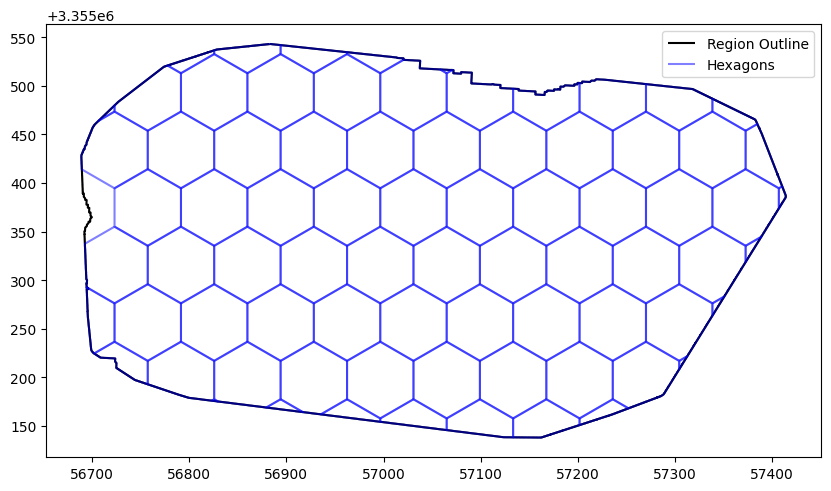

In [113]:
# Define 1-acre target area in square meters
target_area_acres = 1  # 1 acre
target_area_sqm = target_area_acres * 4046.86  # Convert to square meters

# Calculate the side length for a hexagon with the target area
hexagon_side_length = np.sqrt((2 * target_area_sqm) / (3 * np.sqrt(3)))

# Generate the hexagonal grid using the recalculated side length
hex_grid_gdf = generate_hex_grid(contour_proj_polygon, target_area=target_area_sqm)

# Count complete and clipped hexagons
complete_count, clipped_count = count_hexagons(hex_grid_gdf, hexagon_side_length)

# Print results
print(f"Area of the Region: {area_acres:.2f} acres")
print(f"Complete Hexagons: {complete_count}")
print(f"Clipped Hexagons: {clipped_count}")

# Plot the result
fig, ax = plt.subplots(figsize=(10, 10))
gpd.GeoDataFrame({"geometry": [contour_proj_polygon]}).boundary.plot(ax=ax, color="black", label="Region Outline")
hex_grid_gdf.boundary.plot(ax=ax, color="blue", alpha=0.5, label="Hexagons")
plt.legend()
plt.show()


## Irregular Polygon Partitioning

Our hexagons are maximally efficient for packing a 2D region, but we still have a really high proportion of clipped polygons. 

To rectify this and have more "complete" partitions in our region, we will move to irregular, compact polygons.

In [114]:
from scipy.spatial import Voronoi
from shapely.geometry import Point, Polygon
from shapely.ops import voronoi_diagram, unary_union
import numpy as np
import geopandas as gpd

def generate_voronoi_partition(region_polygon, target_area_acres, num_points=None):
    """
    Generate Voronoi partitioning of the region polygon with polygons approximating the target area.
    
    Parameters:
        region_polygon (Polygon): The region to partition.
        target_area_acres (float): Target area for each polygon in acres.
        num_points (int, optional): Number of initial seed points. If None, estimated from the area.

    Returns:
        GeoDataFrame: Clipped Voronoi polygons with their areas.
    """
    # Convert target area to square meters
    target_area_sqm = target_area_acres * 4046.86

    # Estimate number of points if not provided
    if num_points is None:
        num_points = int(region_polygon.area / target_area_sqm)

    print(f"Number of points: {num_points}")

    # Generate random seed points within the polygon
    minx, miny, maxx, maxy = region_polygon.bounds
    points = []
    while len(points) < num_points:
        x, y = np.random.uniform(minx, maxx), np.random.uniform(miny, maxy)
        if region_polygon.contains(Point(x, y)):
            points.append([x, y])

    # Create Voronoi diagram
    vor = Voronoi(points)

    # Extract Voronoi polygons
    voronoi_polygons = []
    for region_idx in vor.regions:
        if not region_idx or -1 in region_idx:  # Ignore invalid regions
            continue
        region_coords = [vor.vertices[i] for i in region_idx]
        polygon = Polygon(region_coords)
        if polygon.is_valid:
            voronoi_polygons.append(polygon)

    # Clip Voronoi polygons to the region
    clipped_polygons = [poly.intersection(region_polygon) for poly in voronoi_polygons]

    # Create GeoDataFrame for the clipped Voronoi polygons
    voronoi_gdf = gpd.GeoDataFrame({"geometry": clipped_polygons}, crs="EPSG:32614")

    return voronoi_gdf


In [115]:
from shapely.geometry import MultiPoint, Polygon
from shapely.ops import voronoi_diagram
import geopandas as gpd
import numpy as np

def generate_voronoi_with_shapely(region_polygon, num_points):
    """
    Generate Voronoi partitioning of a region polygon using shapely's voronoi_polygons.
    
    Parameters:
        region_polygon (Polygon): The polygon defining the region to partition.
        num_points (int): Number of seed points to generate inside the polygon.

    Returns:
        GeoDataFrame: GeoDataFrame containing the clipped Voronoi polygons.
        GeoDataFrame: GeoDataFrame containing the seed points.
    """
    # Generate random points inside the region polygon
    minx, miny, maxx, maxy = region_polygon.bounds
    points = []

    # Keep adding random points in region until we hit our target number
    while len(points) < num_points:
        x, y = np.random.uniform(minx, maxx), np.random.uniform(miny, maxy)
        if region_polygon.contains(Point(x, y)):
            points.append(Point(x, y))

    # Create MultiPoint object from seed points
    multipoint = MultiPoint(points)

    # Generate Voronoi diagram
    voronoi_result = voronoi_diagram(multipoint, envelope=region_polygon, edges=False)

    # Clip Voronoi polygons to the region polygon
    clipped_polygons = [poly.intersection(region_polygon) for poly in voronoi_result.geoms]

    # Create GeoDataFrames for the Voronoi polygons and seed points
    voronoi_gdf = gpd.GeoDataFrame({"geometry": clipped_polygons}, crs="EPSG:32614")
    points_gdf = gpd.GeoDataFrame({"geometry": points}, crs="EPSG:32614")

    return voronoi_gdf, points_gdf

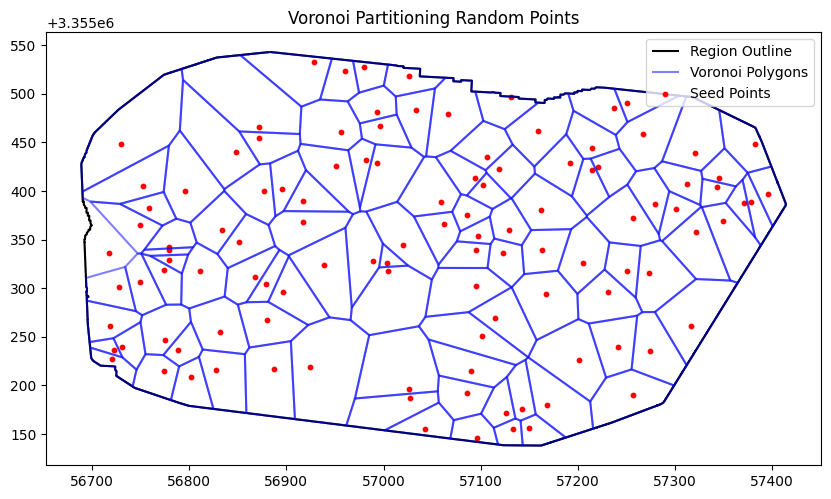

Complete Voronoi Polygons: 48
Clipped Voronoi Polygons: 66
Number of seed points: 114


In [116]:
# Convert target area to square meters
target_area_acres = 0.5
target_area_sqm = target_area_acres * 4046.86
num_points = int(contour_proj_polygon.area / target_area_sqm)


voronoi_gdf, points_gdf = generate_voronoi_with_shapely(contour_proj_polygon, num_points)

# Visualize the result
fig, ax = plt.subplots(figsize=(10, 10))
gpd.GeoDataFrame({"geometry": [contour_proj_polygon]}).boundary.plot(ax=ax, color="black", label="Region Outline")
voronoi_gdf.boundary.plot(ax=ax, color="blue", alpha=0.5, label="Voronoi Polygons")
points_gdf.plot(ax=ax, color="red", markersize=10, label="Seed Points")
plt.legend()
plt.title("Voronoi Partitioning Random Points")
plt.show()


# Count polygons with areas close to the target
complete_count, clipped_count = count_hexagons(voronoi_gdf, hexagon_side_length=np.sqrt((2 * target_area_sqm) / (3 * np.sqrt(3))))

print(f"Complete Voronoi Polygons: {complete_count}")
print(f"Clipped Voronoi Polygons: {clipped_count}")
print(f"Number of seed points: {len(points_gdf)}")

In [117]:
from shapely.geometry import MultiPoint
from shapely.ops import voronoi_diagram
import numpy as np

def centroidal_voronoi_tessellation(region_polygon, num_points, max_iterations=10, tolerance=1e-3):
    """
    Perform Centroidal Voronoi Tessellation (CVT) to refine seed points for uniform partitions.
    
    Parameters:
        region_polygon (Polygon): The region to partition.
        num_points (int): Number of seed points.
        max_iterations (int): Maximum number of iterations for CVT.
        tolerance (float): Convergence threshold for point adjustments.
    
    Returns:
        list: Refined points as shapely.geometry.Point objects.
        GeoDataFrame: Voronoi polygons as GeoDataFrame.
    """
    # Step 1: Generate initial random points
    minx, miny, maxx, maxy = region_polygon.bounds
    points = []
    while len(points) < num_points:
        x, y = np.random.uniform(minx, maxx), np.random.uniform(miny, maxy)
        if region_polygon.contains(Point(x, y)):
            points.append(Point(x, y))

    # Step 2: Iteratively refine points
    for iteration in range(max_iterations):
        # Create Voronoi diagram
        multipoint = MultiPoint(points)
        voronoi_result = voronoi_diagram(multipoint, envelope=region_polygon, edges=False)

        # Compute centroids of Voronoi polygons
        new_points = []
        for poly in voronoi_result.geoms:
            clipped_poly = poly.intersection(region_polygon)
            if clipped_poly.is_valid and not clipped_poly.is_empty:
                new_points.append(clipped_poly.centroid)
        
        # Check for convergence (small adjustments)
        max_shift = max(point.distance(new_point) for point, new_point in zip(points, new_points))
        points = new_points  # Update points for next iteration

        if max_shift < tolerance:
            print(f"Converged after {iteration+1} iterations.")
            break
    else:
        print("Reached maximum iterations without full convergence.")

    # Create Voronoi polygons GeoDataFrame
    clipped_polygons = [poly.intersection(region_polygon) for poly in voronoi_result.geoms]
    voronoi_gdf = gpd.GeoDataFrame({"geometry": clipped_polygons}, crs="EPSG:32614")

    return points, voronoi_gdf

Reached maximum iterations without full convergence.


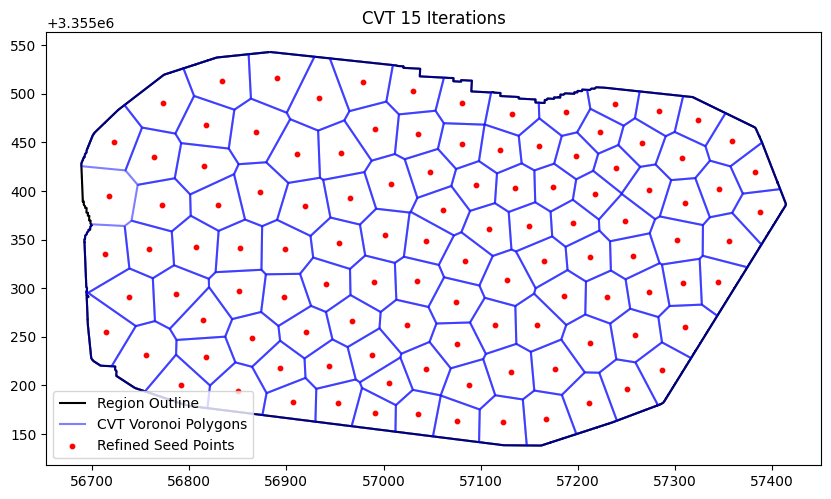

In [118]:
# Results from 15 iterations
# -------------------------

# num_points # Inherit from above
max_iterations = 15
cvt_points, cvt_voronoi_gdf_15 = centroidal_voronoi_tessellation(contour_proj_polygon, num_points, max_iterations)

# Visualize the result
cvt_points_gdf_15 = gpd.GeoDataFrame({"geometry": cvt_points}, crs="EPSG:32614")

fig, ax = plt.subplots(figsize=(10, 10))
gpd.GeoDataFrame({"geometry": [contour_proj_polygon]}).boundary.plot(ax=ax, color="black", label="Region Outline")
cvt_voronoi_gdf_15.boundary.plot(ax=ax, color="blue", alpha=0.5, label="CVT Voronoi Polygons")
cvt_points_gdf_15.plot(ax=ax, color="red", markersize=10, label="Refined Seed Points")
plt.legend()
plt.title("CVT 15 Iterations")
plt.show()

Reached maximum iterations without full convergence.


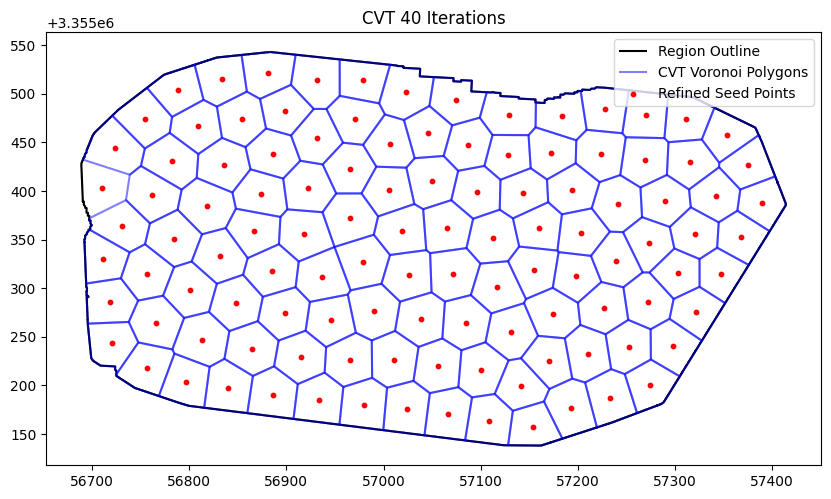

In [119]:
# Results from 40 iterations
# -------------------------

# num_points # Inherit from above
max_iterations = 40
cvt_points, cvt_voronoi_gdf_40 = centroidal_voronoi_tessellation(contour_proj_polygon, num_points, max_iterations)

# Visualize the result
cvt_points_gdf_40 = gpd.GeoDataFrame({"geometry": cvt_points}, crs="EPSG:32614")

fig, ax = plt.subplots(figsize=(10, 10))
gpd.GeoDataFrame({"geometry": [contour_proj_polygon]}).boundary.plot(ax=ax, color="black", label="Region Outline")
cvt_voronoi_gdf_40.boundary.plot(ax=ax, color="blue", alpha=0.5, label="CVT Voronoi Polygons")
cvt_points_gdf_40.plot(ax=ax, color="red", markersize=10, label="Refined Seed Points")
plt.legend()
plt.title("CVT 40 Iterations")
plt.show()

### Centroid Voronoi Tessalation Analysis

We know that the regions created here are entirely arbitrary. The actual business objective behind this is to take a large region and break it into smaller, trackable, billable, and roughly even chunks of work. 

When analyzing the results of this code, we want to know:
- How big is the average region?
- Size of median region?
- Smallest area (and corresponding error)?
- Largest area (and corresponding error)?
- How does this compare to our initial (random) seed?


In [120]:
import pandas as pd

def analyze_voronoi_regions(voronoi_gdf, target_area_acres):
    """
    Analyze Voronoi regions to compute statistics and compare with target area.
    
    Parameters:
        voronoi_gdf (GeoDataFrame): GeoDataFrame containing Voronoi polygons.
        target_area_acres (float): Target area for each region in acres.
    
    Returns:
        pd.DataFrame: Summary statistics for the Voronoi regions.
    """
    # Convert target area to square meters
    target_area_sqm = target_area_acres * 4046.86

    # Calculate areas of Voronoi regions (in square meters and acres)
    voronoi_gdf["area_sqm"] = voronoi_gdf.geometry.area
    voronoi_gdf["area_acres"] = voronoi_gdf["area_sqm"] / 4046.86
    voronoi_gdf["error"] = (voronoi_gdf["area_acres"] - target_area_acres).abs()

    # Compute statistics
    avg_area = voronoi_gdf["area_acres"].mean()
    median_area = voronoi_gdf["area_acres"].median()
    std_dev_area = voronoi_gdf["area_acres"].std()
    smallest_area = voronoi_gdf["area_acres"].min()
    smallest_error = voronoi_gdf.loc[voronoi_gdf["area_acres"].idxmin(), "error"]
    largest_area = voronoi_gdf["area_acres"].max()
    largest_error = voronoi_gdf.loc[voronoi_gdf["area_acres"].idxmax(), "error"]

    # Create a summary DataFrame
    summary = pd.DataFrame({
        "Metric": ["Average Area", "Median Area", "Std Dev Area", "Smallest Area", "Largest Area"],
        "Value (acres)": [avg_area, median_area, std_dev_area, smallest_area, largest_area],
        "Error (acres)": [None, None, None, smallest_error, largest_error]
    })

    return summary, voronoi_gdf



Summary of Initial Seed Results:


,Metric,Value (acres),Error (acres)
0,Average Area,0.502207,NaN
1,Median Area,0.436258,NaN
2,Std Dev Area,0.297076,NaN
3,Smallest Area,0.081855,0.418145
4,Largest Area,1.726307,1.226307


Summary of CVT Results (15 iter):


,Metric,Value (acres),Error (acres)
0,Average Area,0.502207,NaN
1,Median Area,0.487698,NaN
2,Std Dev Area,0.093505,NaN
3,Smallest Area,0.325030,0.174970
4,Largest Area,0.751807,0.251807


Summary of CVT Results (40 iter):


,Metric,Value (acres),Error (acres)
0,Average Area,0.502207,NaN
1,Median Area,0.505126,NaN
2,Std Dev Area,0.035380,NaN
3,Smallest Area,0.423806,0.076194
4,Largest Area,0.584379,0.084379


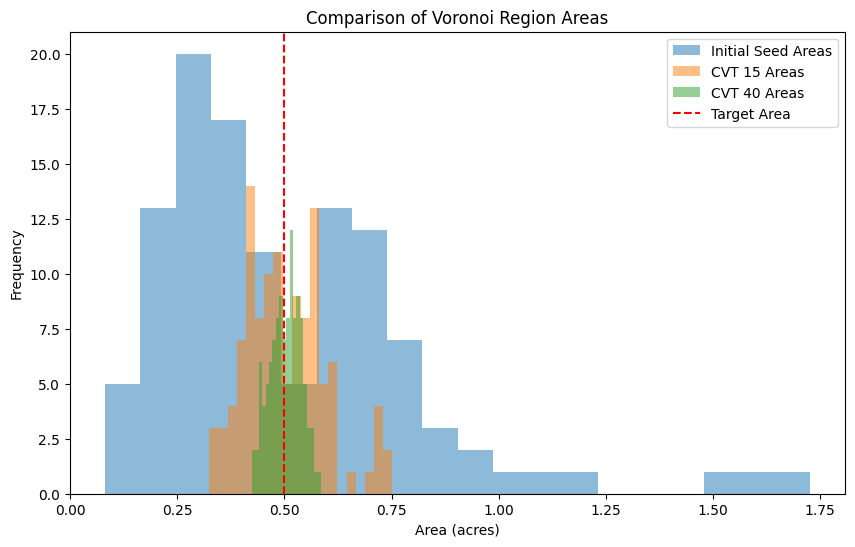

In [121]:

# Analyze CVT results
target_area_acres = 0.5  # in acres

initial_voronoi_summary, initial_voronoi_gdf = analyze_voronoi_regions(voronoi_gdf, target_area_acres)
cvt_15_summary, cvt_15_voronoi_gdf = analyze_voronoi_regions(cvt_voronoi_gdf_15, target_area_acres)
cvt_40_summary, cvt_40_voronoi_gdf = analyze_voronoi_regions(cvt_voronoi_gdf_40, target_area_acres)

# Compare results
print("\nSummary of Initial Seed Results:")
display(initial_voronoi_summary)

print("Summary of CVT Results (15 iter):")
display(cvt_15_summary)

print("Summary of CVT Results (40 iter):")
display(cvt_40_summary)

# Visualize comparison (optional)
fig, ax = plt.subplots(figsize=(10, 6))
initial_voronoi_gdf["area_acres"].plot.hist(bins=20, alpha=0.5, label="Initial Seed Areas", ax=ax)
cvt_15_voronoi_gdf["area_acres"].plot.hist(bins=20, alpha=0.5, label="CVT 15 Areas", ax=ax)
cvt_40_voronoi_gdf["area_acres"].plot.hist(bins=20, alpha=0.5, label="CVT 40 Areas", ax=ax)


plt.axvline(target_area_acres, color="red", linestyle="--", label="Target Area")
plt.title("Comparison of Voronoi Region Areas")
plt.xlabel("Area (acres)")
plt.ylabel("Frequency")
plt.legend()
plt.show()
